# 1 — Create a BeeS-selected UltraFeedback dataset for OLMo 2 1B

This notebook reproduces the three BeeS stages for
`HuggingFaceH4/ultrafeedback_binarized`: in-distribution proxy DPO, implicit/external
margin calculation, and Bayesian aggregation. It uses the original UltraFeedback GPT-4 judge-score
margin as the external signal and a full-parameter OLMo 2 1B proxy as the implicit signal.

The workflow is intentionally conservative:

- no LoRA, PEFT, QLoRA, or 4/8-bit model weights;
- no response truncation—over-length pairs are removed before scoring;
- exact dataset/model revisions are recorded;
- proxy training and scoring use both GPUs;
- long stages are checkpointed or append-only and can be resumed;
- every cache and artifact stays inside the current `VPDPO` workspace.

Expect proxy training and scoring all ~61k preference pairs to take a long time on RTX 20-series
GPUs. That is normal; do not interrupt a stage merely because it is slow.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys


def locate_bees() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "BeeS", cwd.parent, cwd.parent / "BeeS"]
    for candidate in candidates:
        if (candidate / "ReadME.md").exists() and (candidate / "sampler.py").exists():
            return candidate
    raise FileNotFoundError("Open this notebook from VPDPO, BeeS, or BeeS/notebooks")


PROJECT_ROOT = locate_bees()
WORKSPACE = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from olmo2_bees.common import configure_workspace, run_streaming, sha256_file, write_json

CACHE_ENV = configure_workspace(WORKSPACE)
print("BeeS repo:", PROJECT_ROOT)
print("Workspace:", WORKSPACE)
print(json.dumps(CACHE_ENV, indent=2))


BeeS repo: /media/fezan/ASi/VPDPO/BeeS
Workspace: /media/fezan/ASi/VPDPO
{
  "HF_HOME": "/media/fezan/ASi/VPDPO/.cache/huggingface",
  "HF_HUB_CACHE": "/media/fezan/ASi/VPDPO/.cache/huggingface/hub",
  "HUGGINGFACE_HUB_CACHE": "/media/fezan/ASi/VPDPO/.cache/huggingface/hub",
  "HF_DATASETS_CACHE": "/media/fezan/ASi/VPDPO/.cache/huggingface/datasets",
  "TRANSFORMERS_CACHE": "/media/fezan/ASi/VPDPO/.cache/huggingface/hub",
  "TORCH_HOME": "/media/fezan/ASi/VPDPO/.cache/torch",
  "XDG_CACHE_HOME": "/media/fezan/ASi/VPDPO/.cache",
  "PIP_CACHE_DIR": "/media/fezan/ASi/VPDPO/.cache/pip",
  "TRITON_CACHE_DIR": "/media/fezan/ASi/VPDPO/.cache/triton",
  "WANDB_CACHE_DIR": "/media/fezan/ASi/VPDPO/.cache/wandb/cache",
  "WANDB_DIR": "/media/fezan/ASi/VPDPO/artifacts/wandb",
  "TMPDIR": "/media/fezan/ASi/VPDPO/.tmp"
}


## Install the pinned runtime

The cache is workspace-local. PyTorch is deliberately not reinstalled because CUDA wheels are
system-specific; the next cell verifies the existing CUDA build. Set `INSTALL_DEPENDENCIES=False`
after the first successful installation if desired.


In [2]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    run_streaming(
        [sys.executable, "-m", "pip", "install", "-r", str(PROJECT_ROOT / "requirements-olmo2.txt")],
        cwd=PROJECT_ROOT,
    )


$ /home/fezan/miniconda3/bin/python -m pip install -r /media/fezan/ASi/VPDPO/BeeS/requirements-olmo2.txt


  Using cached transformers-5.14.1-py3-none-any.whl.metadata (32 kB)


  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)


  Using cached trl-1.9.0-py3-none-any.whl.metadata (12 kB)


  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
  Using cached huggingface_hub-1.27.0-py3-none-any.whl.metadata (16 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 30/31 [lm_eval]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/31 [lm_eval]

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-cli-base 0.6.0 requires click<8.2, but you have click 8.4.2 which is incompatible.
sd3-steering-lab 0.1.0 requires diffusers<0.38,>=0.35.0, but you have diffusers 0.30.2 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from olmo2_bees.common import assert_two_turing_gpus, package_versions

gpus = assert_two_turing_gpus()
versions = package_versions(
    ["torch", "transformers", "datasets", "accelerate", "trl", "bitsandbytes", "tqdm"]
)
print(json.dumps({"gpus": gpus, "packages": versions}, indent=2))

assert all(not gpu["bf16_supported"] for gpu in gpus), (
    "This notebook is tuned for the installed RTX 20-series pair. Review precision settings if hardware changed."
)


{
  "gpus": [
    {
      "index": 0,
      "name": "NVIDIA GeForce RTX 2080 Ti",
      "memory_gib": 10.74,
      "compute_capability": "7.5",
      "bf16_supported": false
    },
    {
      "index": 1,
      "name": "NVIDIA GeForce RTX 2080 SUPER",
      "memory_gib": 7.78,
      "compute_capability": "7.5",
      "bf16_supported": false
    }
  ],
  "packages": {
    "torch": "2.10.0",
    "transformers": "5.14.1",
    "datasets": "5.0.0",
    "accelerate": "1.14.0",
    "trl": "1.9.0",
    "bitsandbytes": "0.49.2",
    "tqdm": "4.67.1"
  }
}


## Configuration

`MAX_LENGTH=1024` is sized to the smaller 8 GB GPU. Pairs above that limit are excluded losslessly;
the notebook never clips an answer. `SELECTION_SIZE=6000` is about 10% of the unfiltered training
split, matching the high-data-efficiency UltraFeedback setting discussed in the BeeS paper.


In [4]:
MODEL_ID = "allenai/OLMo-2-0425-1B-SFT"
DATASET_ID = "HuggingFaceH4/ultrafeedback_binarized"
MAX_LENGTH = 1024
PROXY_SEED_SIZE = 2_000
SELECTION_SIZE = 6_000
SEED = 42
NUM_PROC = min(8, os.cpu_count() or 1)

ARTIFACTS = WORKSPACE / "artifacts" / "olmo2_bees"
DATA_ROOT = ARTIFACTS / "dataset_work"
PREPARED = DATA_ROOT / "prepared"
PROXY_SEED = DATA_ROOT / "proxy_seed"
PREPARE_METADATA = DATA_ROOT / "prepare_metadata.json"
PROXY_RUN = ARTIFACTS / "proxy_dpo"
PROXY_MODEL = PROXY_RUN / "final"
SCORES_DIR = ARTIFACTS / "implicit_scores"
SCORES_FILE = SCORES_DIR / "implicit_scores.jsonl"
SELECTED_DATASET = ARTIFACTS / "ultrafeedback_bees_olmo2_1b"

for directory in (ARTIFACTS, DATA_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "prepared": str(PREPARED),
    "proxy_seed": str(PROXY_SEED),
    "proxy_model": str(PROXY_MODEL),
    "scores": str(SCORES_FILE),
    "selected_dataset": str(SELECTED_DATASET),
}, indent=2))


{
  "prepared": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/prepared",
  "proxy_seed": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/proxy_seed",
  "proxy_model": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/proxy_dpo/final",
  "scores": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/implicit_scores/implicit_scores.jsonl",
  "selected_dataset": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/ultrafeedback_bees_olmo2_1b"
}


## Stage A — Download, normalize, validate, and tokenize

The source revision is resolved once and written to `prepare_metadata.json`. The source's full
dialogues are converted to TRL's `{prompt, chosen-completion, rejected-completion}` conversational
schema before OLMo's official tokenizer/chat template measures lengths.


In [5]:
prepare_command = [
    sys.executable, "-m", "olmo2_bees.prepare_dataset",
    "--workspace", str(WORKSPACE),
    "--output-root", str(DATA_ROOT),
    "--model-id", MODEL_ID,
    "--dataset-id", DATASET_ID,
    "--max-length", str(MAX_LENGTH),
    "--seed-size", str(PROXY_SEED_SIZE),
    "--seed", str(SEED),
    "--num-proc", str(NUM_PROC),
]
run_streaming(prepare_command, cwd=PROJECT_ROOT)

prepare_metadata = json.loads(PREPARE_METADATA.read_text())
print(json.dumps(prepare_metadata, indent=2))


$ /home/fezan/miniconda3/bin/python -m olmo2_bees.prepare_dataset --workspace /media/fezan/ASi/VPDPO --output-root /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work --model-id allenai/OLMo-2-0425-1B-SFT --dataset-id HuggingFaceH4/ultrafeedback_binarized --max-length 1024 --seed-size 2000 --seed 42 --num-proc 8


Prepared data already exists at /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work; use --force to rebuild


{
  "bees_upstream_commit": "749faf478e2827dd72835d574693623926a2e444",
  "dataset_id": "HuggingFaceH4/ultrafeedback_binarized",
  "dataset_revision": "3949bf5f8c17c394422ccfab0c31ea9c20bdeb85",
  "lossless_length_filter": true,
  "max_length": 1024,
  "method": "BeeS (Bayesian Aggregation for Preference data Selection)",
  "model_id": "allenai/OLMo-2-0425-1B-SFT",
  "model_revision": "0d85a3d037876ce6ac7d4311d994400fc66ac27f",
  "packages": {
    "datasets": "5.0.0",
    "huggingface-hub": "1.27.0",
    "torch": "2.10.0",
    "tqdm": "4.67.1",
    "transformers": "5.14.1"
  },
  "positive_external_margin_count": 50662,
  "prepared_counts": {
    "test": 1891,
    "train": 57589
  },
  "proxy_seed_size": 2000,
  "seed": 42,
  "source_counts": {
    "test": 2000,
    "train": 61135
  }
}


## Prefetch the pinned OLMo checkpoint once

The upstream checkpoint is downloaded in this single notebook process before either distributed
job starts. Both ranks then reuse the same workspace-local Hub snapshot instead of racing to fetch a
roughly 6 GB model.


In [6]:
from huggingface_hub import snapshot_download

model_snapshot = Path(snapshot_download(
    repo_id=MODEL_ID,
    revision=prepare_metadata["model_revision"],
))
assert str(model_snapshot).startswith(str((WORKSPACE / ".cache").resolve()))
print("Pinned model snapshot:", model_snapshot)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Pinned model snapshot: /media/fezan/ASi/VPDPO/.cache/huggingface/hub/models--allenai--OLMo-2-0425-1B-SFT/snapshots/0d85a3d037876ce6ac7d4311d994400fc66ac27f


In [7]:
from datasets import load_from_disk
from tqdm.auto import tqdm

prepared = load_from_disk(str(PREPARED))
proxy_seed = load_from_disk(str(PROXY_SEED))
print(prepared)
print(proxy_seed)

# Explicit tqdm audit in addition to the progress bars emitted by datasets.map/filter.
for split in ("train", "test"):
    for row in tqdm(prepared[split], desc=f"Auditing {split}"):
        assert row["max_pair_tokens"] <= MAX_LENGTH
        assert row["prompt_tokens"] < row["chosen_tokens"]
        assert row["prompt_tokens"] < row["rejected_tokens"]
        assert row["prompt"][-1]["role"] == "user"
        assert row["chosen"][0]["role"] == "assistant"
        assert row["rejected"][0]["role"] == "assistant"

print("Lossless schema/length audit passed.")


DatasetDict({
    train: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'score_chosen', 'score_rejected', 'row_id', 'external_margin', 'prompt_tokens', 'chosen_tokens', 'rejected_tokens', 'max_pair_tokens'],
        num_rows: 57589
    })
    test: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'score_chosen', 'score_rejected', 'row_id', 'external_margin', 'prompt_tokens', 'chosen_tokens', 'rejected_tokens', 'max_pair_tokens'],
        num_rows: 1891
    })
})
Dataset({
    features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'score_chosen', 'score_rejected', 'row_id', 'external_margin', 'prompt_tokens', 'chosen_tokens', 'rejected_tokens', 'max_pair_tokens'],
    num_rows: 2000
})


Auditing train:   0%|          | 0/57589 [00:00<?, ?it/s]

Auditing test:   0%|          | 0/1891 [00:00<?, ?it/s]

Lossless schema/length audit passed.


## Stage B — Train the in-distribution proxy with full-parameter DPO

Both GPUs run FSDP full sharding simultaneously. The effective batch size is
`1 × 2 GPUs × 8 accumulation = 16`. Parameters and updates remain FP32; FP16 is used only for
loss-scaled mixed-precision compute. The SFT reference log-probabilities are computed before
optimization, allowing the reference model to be released. Paged AdamW uses 32-bit optimizer
states; it does not quantize the model.

Restartable FSDP checkpoints are intentionally large because they preserve full FP32 model and
optimizer state. Only two are retained; budget roughly 55–65 GiB for this proxy run.


In [8]:
if (PROXY_RUN / "training_manifest.json").is_file() and (PROXY_MODEL / "model.safetensors").is_file():
    print("Proxy final model already exists; skipping training:", PROXY_MODEL)
else:
    proxy_command = [
        sys.executable, "-m", "accelerate.commands.launch",
        "--multi_gpu", "--num_processes", "2", "--gpu_ids", "0,1",
        "--mixed_precision", "fp16",
        "-m", "olmo2_bees.train_dpo",
        "--workspace", str(WORKSPACE),
        "--dataset-path", str(PROXY_SEED),
        "--model-id", MODEL_ID,
        "--model-revision", prepare_metadata["model_revision"],
        "--output-dir", str(PROXY_RUN),
        "--run-name", "olmo2-1b-bees-proxy",
        "--max-length", str(MAX_LENGTH),
        "--epochs", "2",
        "--learning-rate", "5e-7",
        "--beta", "0.1",
        "--gradient-accumulation-steps", "8",
        "--save-steps", "100",
        "--num-proc", "4",
        "--seed", str(SEED),
        "--resume",
    ]
    run_streaming(proxy_command, cwd=PROJECT_ROOT)

manifest = json.loads((PROXY_RUN / "training_manifest.json").read_text())
assert manifest["full_parameter_training"] is True
assert manifest["peft_or_lora"] is False
assert manifest["weight_quantization"] is None
assert manifest["optimizer_is_paged"] is True
assert manifest["optimizer_state_bits"] == 32
assert manifest["optimizer"] == "bitsandbytes.optim.PagedAdamW32bit"
assert manifest["fp16_initial_loss_scale"] == 32.0
assert manifest["master_parameter_dtype"] == "float32"
assert manifest["compute_dtype"] == "float16"
assert manifest["saved_weight_dtypes"] == ["F32"]
assert manifest["weight_files_sha256"]
assert manifest["parallelism"] == "FSDP2_FULL_SHARD"
assert manifest["world_size"] == 2
for filename, expected_digest in tqdm(
    manifest["weight_files_sha256"].items(), desc="Verifying proxy FP32 weights"
):
    assert sha256_file(PROXY_MODEL / filename) == expected_digest
print(json.dumps(manifest, indent=2))


Proxy final model already exists; skipping training: /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/proxy_dpo/final


Verifying proxy FP32 weights:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "activation_checkpointing": true,
  "activation_offloading": true,
  "compute_dtype": "float16",
  "dataset_path": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/proxy_seed",
  "final_model": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/proxy_dpo/final",
  "fp16_initial_loss_scale": 32.0,
  "full_parameter_training": true,
  "hyperparameters": {
    "beta": 0.1,
    "dataset_path": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/proxy_seed",
    "epochs": 2.0,
    "eval_split": "test",
    "eval_steps": 100,
    "gradient_accumulation_steps": 8,
    "learning_rate": 5e-07,
    "logging_steps": 1,
    "max_length": 1024,
    "max_steps": -1,
    "model_id": "allenai/OLMo-2-0425-1B-SFT",
    "model_revision": "0d85a3d037876ce6ac7d4311d994400fc66ac27f",
    "num_proc": 4,
    "output_dir": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/proxy_dpo",
    "resume": true,
    "run_name": "olmo2-1b-bees-proxy",
    "save_steps": 100,
    "seed": 42,
    "train_split": "tr

## Stage C — Score the implicit reward margin on both GPUs

For each pair, the script computes
`[log π_proxy(chosen|prompt) − log π_SFT(chosen|prompt)] −
 [log π_proxy(rejected|prompt) − log π_SFT(rejected|prompt)]`.
Each rank appends and flushes its own JSONL file, so rerunning the cell resumes from completed rows.


In [9]:
if SCORES_FILE.is_file() and (SCORES_DIR / "score_manifest.json").is_file():
    print("Merged implicit scores already exist; skipping scoring:", SCORES_FILE)
else:
    score_command = [
        sys.executable, "-m", "accelerate.commands.launch",
        "--multi_gpu", "--num_processes", "2", "--gpu_ids", "0,1",
        "--mixed_precision", "fp16",
        "-m", "olmo2_bees.score_implicit",
        "--workspace", str(WORKSPACE),
        "--dataset-path", str(PREPARED),
        "--split", "train",
        "--reference-model", MODEL_ID,
        "--reference-revision", prepare_metadata["model_revision"],
        "--policy-model", str(PROXY_MODEL),
        "--output-dir", str(SCORES_DIR),
        "--max-length", str(MAX_LENGTH),
    ]
    run_streaming(score_command, cwd=PROJECT_ROOT)

score_manifest = json.loads((SCORES_DIR / "score_manifest.json").read_text())
assert score_manifest["rows"] == len(prepared["train"])
assert score_manifest["world_size"] == 2
assert score_manifest["weight_quantization"] is None
print(json.dumps(score_manifest, indent=2))


Merged implicit scores already exist; skipping scoring: /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/implicit_scores/implicit_scores.jsonl
{
  "dataset_path": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/prepared",
  "max_length": 1024,
  "merged_scores": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/implicit_scores/implicit_scores.jsonl",
  "policy_model": "/media/fezan/ASi/VPDPO/artifacts/olmo2_bees/proxy_dpo/final",
  "reference_model": "allenai/OLMo-2-0425-1B-SFT",
  "reference_revision": "0d85a3d037876ce6ac7d4311d994400fc66ac27f",
  "rows": 57589,
  "split": "train",
  "weight_dtype": "float16",
  "weight_quantization": null,
  "world_size": 2
}


## Stage D — BeeS projection, Bayesian aggregation, and selection

This uses BeeS Appendix A.1's lower bound `L = −2`, dynamic upper-bound stopping conditions, the
paper's linear margin-to-probability projection, and Eq. (3). Only rows with positive margins from
both independent sources are eligible; the highest aggregated probabilities become the train split.


In [10]:
select_command = [
    sys.executable, "-m", "olmo2_bees.select_bees",
    "--workspace", str(WORKSPACE),
    "--prepared-path", str(PREPARED),
    "--scores-path", str(SCORES_FILE),
    "--prepare-metadata", str(PREPARE_METADATA),
    "--output-path", str(SELECTED_DATASET),
    "--selection-size", str(SELECTION_SIZE),
]
run_streaming(select_command, cwd=PROJECT_ROOT)

selected = load_from_disk(str(SELECTED_DATASET))
selection_metadata = json.loads((SELECTED_DATASET / "metadata.json").read_text())
assert len(selected["train"]) == SELECTION_SIZE
assert min(selected["train"]["external_margin"]) > 0
assert min(selected["train"]["implicit_margin"]) > 0
assert selected["train"]["bees_rank"] == list(range(1, SELECTION_SIZE + 1))
print(selected)
print(json.dumps(selection_metadata, indent=2))


$ /home/fezan/miniconda3/bin/python -m olmo2_bees.select_bees --workspace /media/fezan/ASi/VPDPO --prepared-path /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/prepared --scores-path /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/implicit_scores/implicit_scores.jsonl --prepare-metadata /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/dataset_work/prepare_metadata.json --output-path /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/ultrafeedback_bees_olmo2_1b --selection-size 6000


Selected dataset already exists at /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/ultrafeedback_bees_olmo2_1b; use --force to rebuild


DatasetDict({
    train: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'score_chosen', 'score_rejected', 'row_id', 'external_margin', 'prompt_tokens', 'chosen_tokens', 'rejected_tokens', 'max_pair_tokens', 'implicit_margin', 'external_preference_probability', 'implicit_preference_probability', 'bees_probability', 'bees_rank'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'score_chosen', 'score_rejected', 'row_id', 'external_margin', 'prompt_tokens', 'chosen_tokens', 'rejected_tokens', 'max_pair_tokens'],
        num_rows: 1891
    })
})
{
  "bees_upstream_commit": "749faf478e2827dd72835d574693623926a2e444",
  "bounds": {
    "external_upper": 8.5,
    "implicit_upper": 90.0,
    "lower": -2.0
  },
  "margin_summary": {
    "external_max": 8.5,
    "external_median": 1.0,
    "external_min": 0.0,
    "implicit_max": 180.386474609375,
    "implicit_median": 1.19000244140625,
    "implicit_min

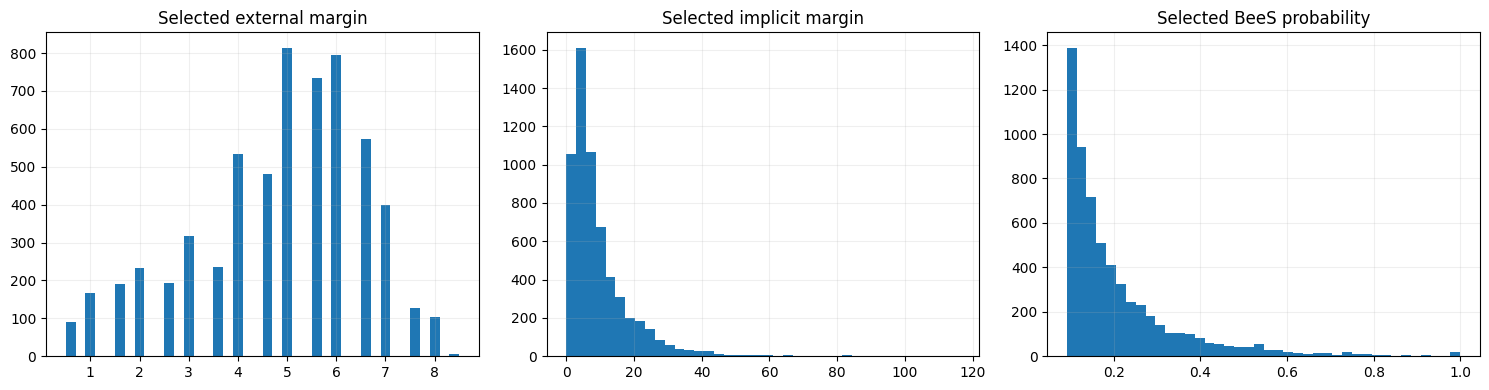

Dataset ready: /media/fezan/ASi/VPDPO/artifacts/olmo2_bees/ultrafeedback_bees_olmo2_1b
Next: run 02_train_olmo2_1b_dpo.ipynb


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(selected["train"]["external_margin"], bins=40)
axes[0].set_title("Selected external margin")
axes[1].hist(selected["train"]["implicit_margin"], bins=40)
axes[1].set_title("Selected implicit margin")
axes[2].hist(selected["train"]["bees_probability"], bins=40)
axes[2].set_title("Selected BeeS probability")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Dataset ready:", SELECTED_DATASET)
print("Next: run 02_train_olmo2_1b_dpo.ipynb")
